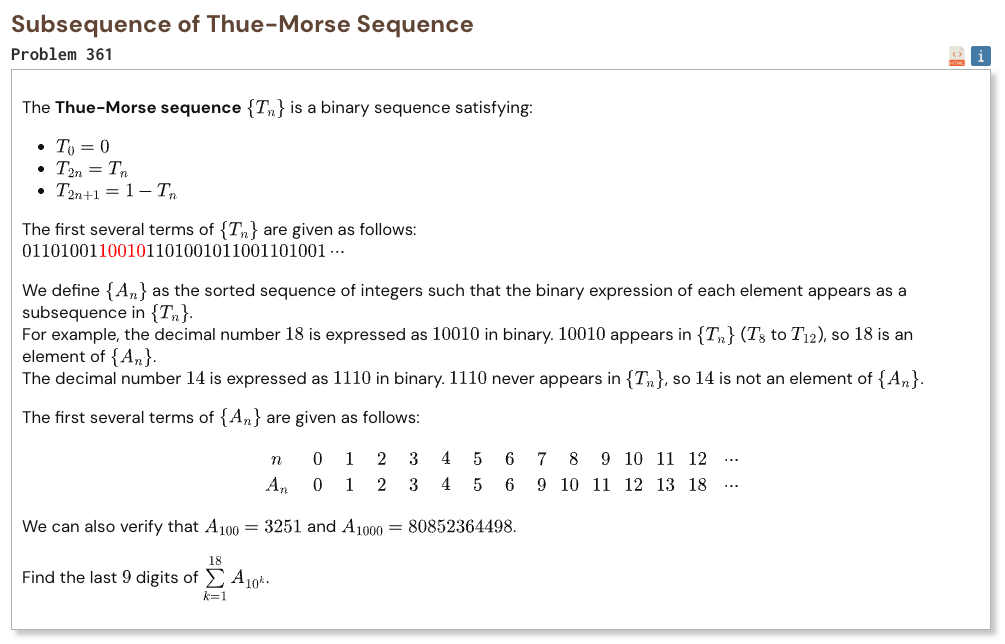

## Initial approach

* count valid binary words by length instead of scanning integers
* use the recursive structure of Thue-Morse factors
* find which word length contains the required index
* build only the exact ranked word symbolically
* evaluate the binary value modulo one billion
* use functools for memoization because many recursive states repeat
* verify the given checks before summing the target terms

In [1]:
from functools import lru_cache

MOD = 10 ** 9

@lru_cache(None)
def count_start1(length):
    if length == 1:
        return 1
    if length == 2:
        return 2
    if length == 3:
        return 3

    half = length // 2

    if length % 2 == 0:
        return count_start1(half) + count_start1(half + 1)

    return 2 * count_start1(half + 1)

@lru_cache(None)
def count_prefix(length):
    if length == 0:
        return 0
    if length == 1:
        return 1
    if length == 2:
        return 3
    if length == 3:
        return 6

    half = length // 2

    if length % 2 == 0:
        return 3 * count_prefix(half) + count_prefix(half + 1) - 4

    return count_prefix(2 * half) + 2 * count_start1(half + 1)

def find_length(index):
    lo = 1
    hi = 1

    while count_prefix(hi) < index:
        hi *= 2

    while lo < hi:
        mid = (lo + hi) // 2

        if count_prefix(mid) >= index:
            hi = mid
        else:
            lo = mid + 1

    return lo

class Node:
    def __init__(self, kind, child=None, length=0, value=""):
        self.kind = kind
        self.child = child
        self.length = length
        self.value = value

EMPTY = Node("lit", None, 0, "")

def node_lit(s):
    return Node("lit", None, len(s), s)

def node_comp(child):
    if child.length == 0:
        return child

    return Node("comp", child, child.length)

def node_even(child, length):
    return Node("even", child, length)

def node_odd(child, length):
    return Node("odd", child, length)

first_cache = {}
last_cache = {}
drop_first_cache = {}
drop_last_cache = {}

def first_bit(node):
    if node in first_cache:
        return first_cache[node]

    if node.kind == "lit":
        value = int(node.value[0])
    elif node.kind == "comp":
        value = 1 - first_bit(node.child)
    elif node.kind == "even":
        value = first_bit(node.child)
    else:
        value = 1 - first_bit(node.child)

    first_cache[node] = value
    return value

def last_bit(node):
    if node in last_cache:
        return last_cache[node]

    if node.kind == "lit":
        value = int(node.value[-1])
    elif node.kind == "comp":
        value = 1 - last_bit(node.child)
    elif node.kind == "even":
        if node.length % 2 == 0:
            value = 1 - last_bit(node.child)
        else:
            value = last_bit(node.child)
    else:
        if node.length % 2 == 0:
            value = last_bit(node.child)
        else:
            value = 1 - last_bit(node.child)

    last_cache[node] = value
    return value

def drop_first(node):
    if node.length == 0:
        return node
    if node.length == 1:
        return EMPTY
    if node in drop_first_cache:
        return drop_first_cache[node]

    if node.kind == "lit":
        result = node_lit(node.value[1:])
    elif node.kind == "comp":
        result = node_comp(drop_first(node.child))
    elif node.kind == "even":
        result = node_odd(node.child, node.length - 1)
    else:
        result = node_even(drop_first(node.child), node.length - 1)

    drop_first_cache[node] = result
    return result

def drop_last(node):
    if node.length == 0:
        return node
    if node.length == 1:
        return EMPTY
    if node in drop_last_cache:
        return drop_last_cache[node]

    if node.kind == "lit":
        result = node_lit(node.value[:-1])
    elif node.kind == "comp":
        result = node_comp(drop_last(node.child))
    elif node.kind == "even":
        if node.length % 2 == 0:
            result = node_even(node.child, node.length - 1)
        else:
            result = node_even(drop_last(node.child), node.length - 1)
    else:
        if node.length % 2 == 0:
            result = node_odd(drop_last(node.child), node.length - 1)
        else:
            result = node_odd(node.child, node.length - 1)

    drop_last_cache[node] = result
    return result

def max_depth(length):
    depth = 0

    while length > 3:
        length = length // 2 + 1
        depth += 1

    return depth

def build_kmax():
    largest = 0

    for k in range(1, 19):
        largest = max(largest, find_length(10 ** k))

    return max_depth(largest) + 2

KMAX = build_kmax()
POWERS = [pow(2, 2 ** k, MOD) for k in range(KMAX + 2)]

pow_cache = {}
geom_cache = {}
eval_cache = {}
mu_cache = {}

def pow_x(k, exponent):
    key = (k, exponent)

    if key not in pow_cache:
        pow_cache[key] = pow(POWERS[k], exponent, MOD)

    return pow_cache[key]

def geom_sum(base, count):
    key = (base, count)

    if key in geom_cache:
        return geom_cache[key]

    if count == 0:
        return 0
    if count == 1:
        return 1

    if count % 2 == 0:
        half = geom_sum(base, count // 2)
        result = (half + pow(base, count // 2, MOD) * half) % MOD
    else:
        result = (geom_sum(base, count - 1) + pow(base, count - 1, MOD)) % MOD

    geom_cache[key] = result
    return result

def evals(node):
    if node in eval_cache:
        return eval_cache[node]

    if node.length == 0:
        result = [0] * (KMAX + 2)
        eval_cache[node] = result
        return result

    if node.kind == "lit":
        result = []

        for k in range(KMAX + 2):
            value = 0

            for ch in node.value:
                value = (value * POWERS[k] + (ch == "1")) % MOD

            result.append(value)

    elif node.kind == "comp":
        child = evals(node.child)
        result = []

        for k in range(KMAX + 2):
            result.append((geom_sum(POWERS[k], node.length) - child[k]) % MOD)

    elif node.kind == "even":
        if node.length % 2 == 0:
            child = evals(node.child)
            half = node.length // 2
            result = []

            for k in range(KMAX + 2):
                if k + 1 >= KMAX + 2:
                    value = 0
                else:
                    value = (
                        (POWERS[k] - 1) * child[k + 1]
                        + geom_sum((POWERS[k] * POWERS[k]) % MOD, half)
                    ) % MOD

                result.append(value)
        else:
            prefix = drop_last(node.child)
            final_bit = last_bit(node.child)
            prefix_values = mu_evals(prefix)
            result = [(prefix_values[k] * POWERS[k] + final_bit) % MOD for k in range(KMAX + 2)]

    else:
        half = node.length // 2
        start_bit = first_bit(node.child)
        end_bit = last_bit(node.child)

        if node.length % 2 == 1:
            tail = drop_first(node.child)
            tail_values = mu_evals(tail)
            result = [((1 - start_bit) * pow_x(k, 2 * half) + tail_values[k]) % MOD for k in range(KMAX + 2)]
        else:
            middle = drop_last(drop_first(node.child))
            middle_values = mu_evals(middle)
            result = [
                (
                    (1 - start_bit) * pow_x(k, 2 * half - 1)
                    + middle_values[k] * POWERS[k]
                    + end_bit
                ) % MOD
                for k in range(KMAX + 2)
            ]

    eval_cache[node] = result
    return result

def mu_evals(node):
    if node in mu_cache:
        return mu_cache[node]

    base = evals(node)
    result = []

    for k in range(KMAX + 2):
        if k + 1 >= KMAX + 2:
            value = 0
        else:
            value = (
                (POWERS[k] - 1) * base[k + 1]
                + geom_sum((POWERS[k] * POWERS[k]) % MOD, node.length)
            ) % MOD

        result.append(value)

    mu_cache[node] = result
    return result

small_words = {
    1: ["1"],
    2: ["10", "11"],
    3: ["100", "101", "110"]
}

def kth_word(length, rank, start_bit):
    if start_bit == 0:
        total = count_start1(length)
        return node_comp(kth_word(length, total - 1 - rank, 1))

    if length <= 3:
        return node_lit(small_words[length][rank])

    even_length = (length + 1) // 2
    even_count = count_start1(even_length)

    if rank < even_count:
        return node_even(kth_word(even_length, rank, 1), length)

    odd_length = length // 2 + 1
    return node_odd(kth_word(odd_length, rank - even_count, 0), length)

def node_to_string(node):
    if node.length == 0:
        return ""

    if node.kind == "lit":
        return node.value

    if node.kind == "comp":
        s = node_to_string(node.child)
        return "".join("1" if c == "0" else "0" for c in s)

    if node.kind == "even":
        s = node_to_string(node.child)

        if node.length % 2 == 0:
            return "".join(c + ("1" if c == "0" else "0") for c in s)

        return "".join(c + ("1" if c == "0" else "0") for c in s[:-1]) + s[-1]

    s = node_to_string(node.child)

    if node.length % 2 == 1:
        return ("1" if s[0] == "0" else "0") + "".join(
            c + ("1" if c == "0" else "0")
            for c in s[1:]
        )

    return ("1" if s[0] == "0" else "0") + "".join(
        c + ("1" if c == "0" else "0")
        for c in s[1:-1]
    ) + s[-1]

def A_mod(index):
    if index == 0:
        return 0

    length = find_length(index)
    rank = index - 1 - count_prefix(length - 1)
    node = kth_word(length, rank, 1)

    return evals(node)[0]

def A_exact(index):
    if index == 0:
        return 0

    length = find_length(index)
    rank = index - 1 - count_prefix(length - 1)
    node = kth_word(length, rank, 1)

    return int(node_to_string(node), 2)

def solve():
    total = 0

    for k in range(1, 19):
        total = (total + A_mod(10 ** k)) % MOD

    return total

assert A_exact(100) == 3251
assert A_exact(1000) == 80852364498

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 178476944
CPU times: user 19 ms, sys: 1.18 ms, total: 20.2 ms
Wall time: 19.7 ms
